In [1]:
# Autoencoder

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import joblib
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split

In [2]:
# Project Paths

PROJECT_ROOT = Path.cwd().parent

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

MODEL_DIR = PROJECT_ROOT / "models"

In [3]:
# Device

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cpu


In [4]:
# Load Scaled Data

scaled_df = pd.read_parquet(
    DATA_PROCESSED / "scaled_features.parquet"
)

print(scaled_df.shape)

scaled_df.head()

(93358, 11)


,recency_days,frequency,monetary_value,total_items,freight_to_merchandise_ratio,avg_installments,avg_review_score,review_coverage_ratio,unique_products,unique_categories,unique_sellers
0,-0.461207,0.0,0.375114,0.0,-0.535578,2.000000,0.0,0.0,0.0,0.0,0.0
1,-0.448276,0.0,-0.661422,0.0,0.870328,-0.333333,-1.0,0.0,0.0,0.0,0.0
2,1.375000,0.0,-0.193580,0.0,0.102667,2.000000,-2.0,0.0,0.0,0.0,0.0
3,0.443966,0.0,-0.595214,0.0,1.843668,0.666667,-1.0,0.0,0.0,0.0,0.0
4,0.301724,0.0,0.842956,0.0,-0.529672,1.333333,0.0,0.0,0.0,0.0,0.0


In [5]:
# Validation

validation = pd.Series({
    "rows": len(scaled_df),
    "columns": len(scaled_df.columns),
    "missing_values": scaled_df.isna().sum().sum()
})

validation

rows              93358
columns              11
missing_values        0
dtype: int64

In [6]:
# Train/Validation Split
# We'll keep 80/20. That's a standard, defensible choice.

train_df, val_df = train_test_split(
    scaled_df,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print(train_df.shape)
print(val_df.shape)

(74686, 11)
(18672, 11)


In [7]:
# Convert to Tensor

X_train = torch.tensor(
    train_df.values,
    dtype=torch.float32
)

X_val = torch.tensor(
    val_df.values,
    dtype=torch.float32
)

print(X_train.shape)
print(X_val.shape)

torch.Size([74686, 11])
torch.Size([18672, 11])


In [8]:
# Create DataLoader

from torch.utils.data import TensorDataset, DataLoader

batch_size = 256

train_loader = DataLoader(
    TensorDataset(X_train),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val),
    batch_size=batch_size,
    shuffle=False
)

print(len(train_loader))
print(len(val_loader))

292
73


In [9]:
# Define Autoencoder

class AutoEncoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(11, 8),
            nn.ReLU(),
            nn.Linear(8, 4)
        )

        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 11)
        )

    def forward(self, x):

        latent = self.encoder(x)

        reconstruction = self.decoder(latent)

        return reconstruction

In [10]:
# Initialize Model

model = AutoEncoder().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

model

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=11, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=11, bias=True)
  )
)

In [11]:
# Training Loop

num_epochs = 30

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    # Training
    model.train()

    train_loss = 0

    for (batch,) in train_loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        reconstructed = model(batch)

        loss = criterion(reconstructed, batch)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Validation
    model.eval()

    val_loss = 0

    with torch.no_grad():

        for (batch,) in val_loader:

            batch = batch.to(device)

            reconstructed = model(batch)

            loss = criterion(reconstructed, batch)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.5f} | "
        f"Validation Loss: {val_loss:.5f}"
    )

Epoch 01/30 | Train Loss: 0.67178 | Validation Loss: 0.29992
Epoch 02/30 | Train Loss: 0.23113 | Validation Loss: 0.17116
Epoch 03/30 | Train Loss: 0.15282 | Validation Loss: 0.12607
Epoch 04/30 | Train Loss: 0.12053 | Validation Loss: 0.11144
Epoch 05/30 | Train Loss: 0.09966 | Validation Loss: 0.08139
Epoch 06/30 | Train Loss: 0.07444 | Validation Loss: 0.06821
Epoch 07/30 | Train Loss: 0.06754 | Validation Loss: 0.06462
Epoch 08/30 | Train Loss: 0.06572 | Validation Loss: 0.06347
Epoch 09/30 | Train Loss: 0.06455 | Validation Loss: 0.06296
Epoch 10/30 | Train Loss: 0.06362 | Validation Loss: 0.06161
Epoch 11/30 | Train Loss: 0.06277 | Validation Loss: 0.06201
Epoch 12/30 | Train Loss: 0.06235 | Validation Loss: 0.06060
Epoch 13/30 | Train Loss: 0.06202 | Validation Loss: 0.06054
Epoch 14/30 | Train Loss: 0.06187 | Validation Loss: 0.06036
Epoch 15/30 | Train Loss: 0.06177 | Validation Loss: 0.06036
Epoch 16/30 | Train Loss: 0.06166 | Validation Loss: 0.06057
Epoch 17/30 | Train Loss

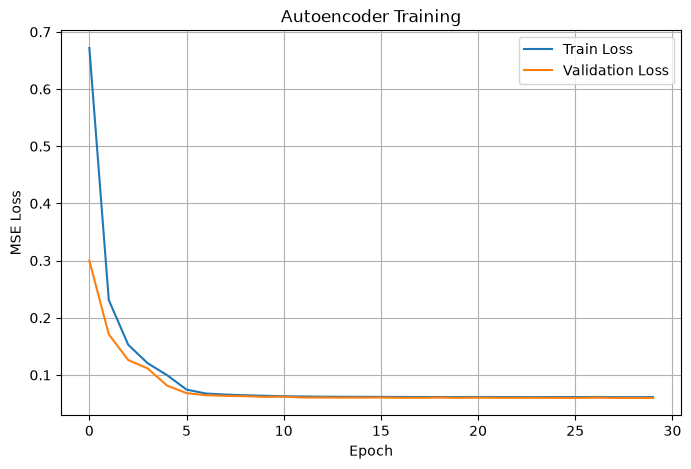

In [12]:
# Loss Curve

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training")

plt.legend()

plt.grid(True)

plt.show()

In [13]:
# Extract Latent Features

model.eval()

with torch.no_grad():

    latent_features = model.encoder(
        torch.tensor(
            scaled_df.values,
            dtype=torch.float32
        ).to(device)
    )

latent_df = pd.DataFrame(
    latent_features.cpu().numpy(),
    columns=[
        "latent_1",
        "latent_2",
        "latent_3",
        "latent_4"
    ]
)

latent_df.head()

,latent_1,latent_2,latent_3,latent_4
0,1.111148,-2.120633,-0.003959,-2.057972
1,-0.132927,-2.316405,1.388605,-1.193602
2,0.905365,-2.913302,1.212862,-3.470234
3,-0.590161,-2.668145,1.046453,-1.992879
4,1.440837,-1.910079,0.204552,-1.695304


In [14]:
# Validation

pd.Series({
    "rows": len(latent_df),
    "columns": len(latent_df.columns),
    "missing_values": latent_df.isna().sum().sum()
})

rows              93358
columns               4
missing_values        0
dtype: int64

In [15]:
# Save Encoder & Latent Features

torch.save(
    model.encoder.state_dict(),
    MODEL_DIR / "encoder.pt"
)

latent_df.to_parquet(
    DATA_PROCESSED / "latent_features.parquet",
    index=False
)

print("Encoder saved.")
print("Latent features saved.")

Encoder saved.
Latent features saved.


In [16]:
# Validate Files

import os

pd.Series({
    "encoder_exists":
        os.path.exists(MODEL_DIR / "encoder.pt"),

    "latent_features_exist":
        os.path.exists(DATA_PROCESSED / "latent_features.parquet")
})

encoder_exists           True
latent_features_exist    True
dtype: bool